In [1]:
%%html
<style type="text/css">
  span.ecb { background: yellow; }
</style>
<span class="ecb">Grading comments will be in yellow</span>

In [2]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# from IPython.display import display
import itertools

# ATMO 5331 - Homework #2
### Spring 2026, Due 26 Feb, 2026, before start of class.

When working these problems, you will need to code up equations for and make plots of various electrostatic quantities. Turn in a Jupyter notebook with your figures and which I can run to reproduce your results. Label your axes like a professional.

Please also enter your derivation into the notebook using $LaTeX$.

Do not copy-paste code; if you feel tempted, write a function that repeats operations that follow a certain template. Those functions can be in the notebook itself, or in an accompanying .py file that you import into the notebook.

Provide any needed discussion as commentary in the notebook in a Markdown cell.

### 1. E from a charged slab

In lecture we used Gauss's law to show that the electric field produced by a thin sheet of charge with surface charge density $\sigma_q$ is given by $E(z) = \sigma_q / 2\epsilon$.

Using a similar approach, derive an expression for the vertical profile of the electric field produced by an inifinitely wide slab of space charge with thickness $H$ whose bottom is at a height of $z_0$ and has charge density $\rho$.

<span class="ecb">(5)</span>.

For outside the slab:

$ z < z_0 $ or $ z > z_0 + H $

From Gauss's Law:

$\oint_{sfc} ~ \vec{E} ~ \cdot ~ \hat{n} ~ dA = q_{encl}/\epsilon$

And knowing:

$ \rho = q/V $

Using our cylinder/pillbox, we have two circles that the flux travels through (one at the top of the slab and one at the bottom). We sum the flux through both circles to get the total flux through the cylinder:

$\oint_{top} ~ \vec{E} ~ \cdot ~ \hat{n} ~ dA_{top} + \oint_{bot} ~ \vec{E} ~ \cdot ~ \hat{n} ~ dA_{bot} = q_{encl}/\epsilon$

Rearrage $\rho$ to obtain $q$ and substitute:

$ q = \rho ~ V$

$ q_{encl}/\epsilon = \rho ~ V_{encl} / \epsilon $

Using the definition of the volume of a cylinder with $h$ being the height of the cylinder:

$ V= A ~ \cdot ~ h $

$ \rho ~ V_{encl} / \epsilon ~ = ~(A ~ \cdot ~ h) / \epsilon $

So:

$\oint_{top} ~ \vec{E} ~ \cdot ~ \hat{n} ~ dA_{top} + \oint_{bot} ~ \vec{E} ~ \cdot ~ \hat{n} ~ dA_{bot} ~ = ~\rho (A ~ \cdot ~ h) / \epsilon $

Taking the integrals, our LHS simplifies to:

$ 2 ~ E(z) ~ A ~ = ~\rho(A ~ \cdot ~ h) / \epsilon $

Isolate $E(z)$:

$ \boxed{E(z) ~ = ~ \rho h / 2\epsilon} $

For inside the slab:

### 2. Plotting E
Using the given equation and the one you derived in problem 1., complete the two functions below, as described by their documentation strings (docstrings).

<span class="ecb">(10)</span>.

In [17]:
epsilon = 8.854e-12 #F/m

def sheet_E(z, z_0, sigma_q):
    """
    Given a height z, return the electric field produced by an
    inifintely thin layer horizontal of charge located at height z_0, 
    with surface charge density sigma_q.
    
    Units:
    """
    # E based on whether you're above the sheet or below the sheet
    E = np.where(z > z_0,
             sigma_q / (2 * epsilon),
             -sigma_q / (2 * epsilon))

    return E

def slab_E(z, z_0, H, rho):
    """ 
    Given a height z, return the electric field produced by an 
    infinite horizontal slab of charge whose bottom is at z_0, top is at z_0+H
    and with constant volumetric charge density rho.
    
    Units:
    """

    # create BCs
    
    outside_top = (z >= z_0 + H)
    outside_bottom = (z <= z_0)
    #inside = ((z < z_0 + H) & (z > z_0))

    inside_top = ((z < z_0 + H) & (z > z_0 + (H/2)))
    inside_bot = ((z < z_0 + (H/2)) & (z > z_0))

    # define our E fields
    
    outside_top_E = (rho * z) / (2 * epsilon)
    outside_bot_E = -(rho * z) / (2 * epsilon)
    inside_top_E = (rho * z) / epsilon
    inside_bot_E = -(rho * z) / epsilon

    BCs = [outside_top, outside_bottom, inside_top, inside_bot]

    E_fields = [outside_top_E, outside_bot_E, inside_top_E, inside_bot_E]

    E = np.select(BCs, E_fields) # finds where BCs are true and sets the appropriate E field
                  

    return E

all_z = np.arange(0, 15e3, 100.0) # Use these altitudes when making plots.

### 3. Plots

Ignoring the effect of a conducting ground plane, 

**a.** Plot the electric field profile produced by an inifinitely thin layer of charge (in isolation) at a cloud top height of 8 km for a surface charge density of +.5 µC/m$^2$.

**b.** Plot the electric field profile produced by an inifinitely thin layer of charge (in isolation) at a cloud bottom height of 5 km for a surface charge density of +.5 µC/m$^2$.

**c.** Plot the electric field profile for a slab (in isolation) using a charge density of -1 nC/m$^3$, bottom height of 6 km, and thickness of 1 km.

**d.** Plot the sum of the electric fields calculated in a,b,c.

<span class="ecb">(5 each, 15 total)</span>.

In [5]:
import matplotlib
# matplotlib.use('WebAgg')
import matplotlib.pyplot as plt

red_blue = plt.get_cmap('RdBu_r')
helix = plt.get_cmap('cubehelix_r')

In [6]:
all_z

array([    0.,   100.,   200.,   300.,   400.,   500.,   600.,   700.,
         800.,   900.,  1000.,  1100.,  1200.,  1300.,  1400.,  1500.,
        1600.,  1700.,  1800.,  1900.,  2000.,  2100.,  2200.,  2300.,
        2400.,  2500.,  2600.,  2700.,  2800.,  2900.,  3000.,  3100.,
        3200.,  3300.,  3400.,  3500.,  3600.,  3700.,  3800.,  3900.,
        4000.,  4100.,  4200.,  4300.,  4400.,  4500.,  4600.,  4700.,
        4800.,  4900.,  5000.,  5100.,  5200.,  5300.,  5400.,  5500.,
        5600.,  5700.,  5800.,  5900.,  6000.,  6100.,  6200.,  6300.,
        6400.,  6500.,  6600.,  6700.,  6800.,  6900.,  7000.,  7100.,
        7200.,  7300.,  7400.,  7500.,  7600.,  7700.,  7800.,  7900.,
        8000.,  8100.,  8200.,  8300.,  8400.,  8500.,  8600.,  8700.,
        8800.,  8900.,  9000.,  9100.,  9200.,  9300.,  9400.,  9500.,
        9600.,  9700.,  9800.,  9900., 10000., 10100., 10200., 10300.,
       10400., 10500., 10600., 10700., 10800., 10900., 11000., 11100.,
      

In [7]:
all_x = np.arange(0, 5e3, 100.0)

In [8]:
all_x

array([   0.,  100.,  200.,  300.,  400.,  500.,  600.,  700.,  800.,
        900., 1000., 1100., 1200., 1300., 1400., 1500., 1600., 1700.,
       1800., 1900., 2000., 2100., 2200., 2300., 2400., 2500., 2600.,
       2700., 2800., 2900., 3000., 3100., 3200., 3300., 3400., 3500.,
       3600., 3700., 3800., 3900., 4000., 4100., 4200., 4300., 4400.,
       4500., 4600., 4700., 4800., 4900.])

In [31]:
z_0a = 8e3
sigma_a = 0.5e-6

z_0b = 5e3
sigma_b = 0.5e-6

z_0c = 6e3
rho_c = -1e-9
H_c = 1e3

E_a = sheet_E(all_z, z_0a, sigma_a)
E_2D_a = E_a[:, None] * np.ones_like(all_x) # make E_a into a 2D field so we can plot x and z

E_b = sheet_E(all_z, z_0b, sigma_b)
E_2D_b = E_b[:, None] * np.ones_like(all_x)

E_c = slab_E(all_z, z_0c, H_c, rho_c)
E_2D_c = E_c[:, None] * np.ones_like(all_x)

E_all = E_a + E_b + E_c
E_all_2D = E_2D_a + E_2D_b + E_2D_c

In [10]:
E_a.shape

(150,)

In [12]:
E_2D_a.shape

(150, 50)

In [27]:
def wind_barbs_uw(E):
    U = np.zeros_like(all_x) # no horizontal component
    W = E * 1e-4 # decrease magnitude so we can actually plot the barbs

    return U, W

In [32]:
U_a, W_a = wind_barbs_uw(E_a)
U_b, W_b = wind_barbs_uw(E_b)
U_c, W_c = wind_barbs_uw(E_c)
U_all, W_all = wind_barbs_uw(E_all)

In [33]:
def e_plot(ax, E_2D, cmap, skips, skipb, U, W):
    skipbig = 6
    skipsmall = 2
    #fieldnorm = matplotlib.colors.Normalize(vmin=min(E_a), vmax=max(E_a))
    
    plot = ax.pcolormesh(all_x, all_z, E_2D, cmap=cmap)
    ax.barbs(all_x[::skips], all_z[::skipb], U[::skips], W[::skipb], barbcolor=['r'])
    plt.colorbar(plot, label='E Field Magnitude (V/m)', ax=ax)
    ax.set_xlabel('Meters in X (m)')
    ax.set_ylabel('Meters in Z (m)')

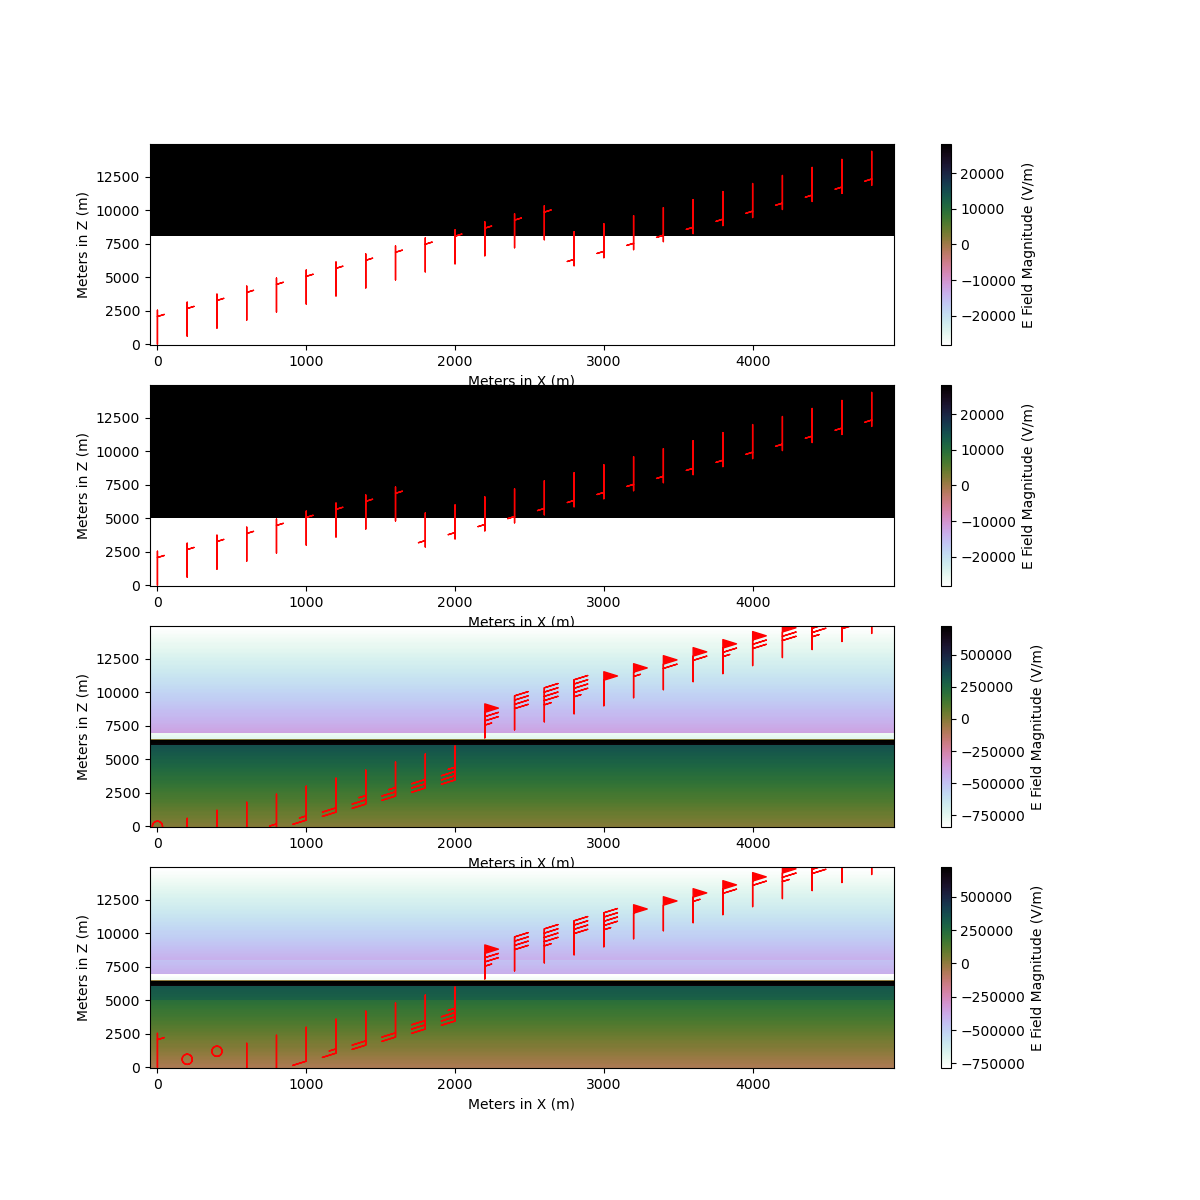

In [35]:
fig, axes = plt.subplots(4,1, figsize=(12,12))

ax_a = axes[0]
ax_b = axes[1]
ax_c = axes[2]
ax_d = axes[3]

skipbig = 6
skipsmall = 2

e_plot(ax_a, E_2D_a, helix, skipsmall, skipbig, U_a, W_a)
e_plot(ax_b, E_2D_b, helix, skipsmall, skipbig, U_b, W_b)
e_plot(ax_c, E_2D_c, helix, skipsmall, skipbig, U_c, W_c)
e_plot(ax_d, E_all_2D, helix, skipsmall, skipbig, U_all, W_all)
plt.show()

In [ ]:
# From HW 1

from fipy import Grid2D, Grid3D, CellVariable, DiffusionTerm
from fipy.tools.numerix import sqrtDot, reshape
import numpy as np

dx = 100.0

mesh = Grid2D(dx=dx, dy=dx, Lx=all_z, Ly=all_z)
X, Z = mesh.cellCenters
print(X.shape, Z.shape, type(X))

In [ ]:
mesh = Grid2D(Lx=all_z, Ly=all_z)

In [ ]:
phi = CellVariable(name = "Potential (V)",
                    mesh = mesh,
                    value = phiGround)
rho = CellVariable(name = "Charge density (C m$^{-3}$)", mesh = mesh)

# Set up the Poisson problem
permittivity = 8.854e-12 # vacuum, F/m
phi.equation = (DiffusionTerm(coeff = permittivity) + rho == 0)

# there is also grad, which is first order. facegrad is second order.
# Efield = -phi.faceGrad
# Finally, we can use leastSquaresGrad, which is calculated at the cell centers.
# This is a bit harder to imagine from the point of view of a discretized gradient calculation
# but has the advantage that we can slice the arrays the same way as the scalar variables.
Efield_a = sheet_E(8, 0, 0.5e-6)
Efield_b = sheet_E(0, 5, 0.5e-6)
Efield_c = slab_E(0, 6, 1e3, -0.1e-9)

# Efield_a.name = 'Electric Field (V/m)'
# Efield_b.name = 'Electric Field (V/m)'
# Efield_c.name = 'Electric Field (V/m)'

# Only need these for faceGrad.
EfaceX, EfaceZ = Efield_a.mesh.faceCenters
print(EfaceX.shape)

In [ ]:
np.shape(Efield_a)

In [ ]:
# Zero E field (gradient of potential) on exterior
phi.faceGrad.constrain(0 * mesh.faceNormals, where=mesh.exteriorFaces)

# Zero potential at ground, overwrites previous condition on bottom boundary
phi.constrain(phiGround, mesh.facesFront)

# Potential provided by ionosphere, approximated as a single upper boundary, i.e., the electrosphere
phi.constrain(phiElectrosphere, mesh.facesBack)
    
print(X.shape, mesh.shape, phi.shape)


In [ ]:
import matplotlib
# matplotlib.use('WebAgg')
import matplotlib.pyplot as plt

red_blue = plt.get_cmap('RdBu_r')
helix = plt.get_cmap('cubehelix_r')

In [ ]:
# reversed shape based on FiPy's matplotlib2DGridViewer source
mesh_shape = mesh.shape[::-1]
plotx, plotz = np.reshape(X, mesh_shape), np.reshape(Z, mesh_shape)
plotrho = np.reshape(rho.value, mesh_shape)

In [ ]:
mesh_shape

In [ ]:
# Find the index along the X and Y dimensions 
# It's a cartesian grid. We have taken the min along the axis we know is repeated across
# the other two dimensions, so the value should be the same across the other two axes, 
# allowing us to select [0,0] or any other index value.
Xci = np.argmin(np.abs(plotx-Xc), axis=-1)[0,0]
Yci = np.argmin(np.abs(ploty-Yc), axis=-2)[0,0]

# Set up the slice location
YZslice = slice(None), slice(None), Xci
XZslice = slice(None), Yci, slice(None)

In [ ]:
f, axs = plt.subplots(3,1,figsize=(10,10))
ax_field_a = axs[0]
ax_field_b = axs[1]
ax_field_c = axs[2]

Emax = 150
fraction = 1.0
fieldnorm = matplotlib.colors.Normalize(vmin=0, vmax=Emax)


Emagplot = np.reshape(Efield_a.mag.value*1e-3, mesh_shape) # make Efield from shape (200, ) --> (20, 10) # why *1e-3 ?
print(Emagplot.shape)
Explot = np.reshape(Efield_a.value*1e-3, mesh_shape)
#Eyplot = np.reshape(Efield_a[1, :].value*1e-3, mesh_shape)
Ezplot = np.reshape(Efield_a.value*1e-3, mesh_shape)

Explot = np.reshape(Emagplot[0, :].value*1e-3, mesh_shape)
print(Explot.shape)
Ezplot = Emagplot[1, :]


# Select center along Y to plot Z vs. X
# field_plot_a = ax_field_a.pcolormesh(plotx[XZslice], plotz[XZslice], Emagplot[XZslice], cmap=helix, norm=fieldnorm)
# subset = ((np.random.rand(*Emagplot[XZslice].shape) < fraction) &
#           (Emagplot[XZslice] < Emax)
#          )
# field_barb_EW = ax_field_EW.barbs(plotx[XZslice][subset], plotz[XZslice][subset],
#                                   Explot[XZslice][subset], Ezplot[XZslice][subset], 
#                                   color='k', length=5)

field_plot_a = ax_field_a.pcolormesh(plotx, plotz, Emagplot, cmap=helix, norm=fieldnorm)
subset = ((np.random.rand(*Emagplot.shape) < fraction) &
          (Emagplot < Emax)
         )
field_barb_a = ax_field_a.barbs(plotx[subset], plotz[subset],
                                  Explot[subset], Ezplot[subset], 
                                  color='k', length=5)
ax_field_a.set_xlabel("East distance (X, m)")
ax_field_a.set_ylabel("Altitude (Z, m)")
ax_field_a.set_title("Electric field (kV/m)")
plt.colorbar(field_plot_a, ax=ax_field_a)

field_plot_NS = ax_field_NS.pcolormesh(ploty[YZslice], plotz[YZslice], Emagplot[YZslice], cmap=helix, norm=fieldnorm)
subset = ((np.random.rand(*Emagplot[YZslice].shape) < fraction) &
          (Emagplot[YZslice] < Emax)
         )
field_barb_NS = ax_field_NS.barbs(ploty[YZslice][subset], plotz[YZslice][subset],
                                  Eyplot[YZslice][subset], Ezplot[YZslice][subset], 
                                  color='k', length=5)
ax_field_NS.set_xlabel("North distance (Y, m)")
ax_field_NS.set_ylabel("Altitude (Z, m)")
plt.colorbar(field_plot_NS, ax=ax_field_NS)

### 4. Combining charge and the effect of conductivity

Taking into account the conductivity difference of the cloud $\sigma_{\mathrm{cld}}$ and the clear air $\sigma_{\mathrm{clr}}$, use MacGorman and Rust eq. 2.4 (below) to derive an expression for the top and bottom surface charge densities $(\sigma_{q top}, \sigma_{q bot}$) as a function of the electric field at the top and bottom of the cloud. Here, we let the field inside the cloud determine the necessary "screening" charge that develops to equalize the electric field inside and outside the cloud. Assume that the ratio $\alpha = \sigma_{\mathrm{clr}}/ \sigma_{\mathrm{cld}}$ of clear and cloudy air conductivities is constant with height.

$
\begin{eqnarray}
E_{clr}(z_{top}) = E(z_{top}) + \frac{\sigma_{q top}}{2\epsilon} + \frac{\sigma_{q bot}}{2\epsilon}
\end{eqnarray}
$

$
\begin{eqnarray}
E_{cld}(z_{top}) = E(z_{top}) - \frac{\sigma_{q top}}{2\epsilon} + \frac{\sigma_{q bot}}{2\epsilon}
\end{eqnarray}
$

$
\begin{eqnarray}
E_{cld}(z_{bot}) = E(z_{bot}) - \frac{\sigma_{q top}}{2\epsilon} + \frac{\sigma_{q bot}}{2\epsilon}
\end{eqnarray}
$

$
\begin{eqnarray}
E_{clr}(z_{bot}) = E(z_{bot}) - \frac{\sigma_{q top}}{2\epsilon} - \frac{\sigma_{q bot}}{2\epsilon}
\end{eqnarray}
$

<span class="ecb">(10)</span>.


### 5. Plot the combined cloud 

Assuming a cloud base of $z=5$ km and a cloud top of $z=8$ km, the slab of charge from problem **3c.**, and the formula you derived for **4.**, plot the electric field profile produced by the combined effect of the slab of charge and the effect of the screening charge at the cloud boundary. Let $\alpha = 10$. Again ignore the effect of a conducting ground plane.

<span class="ecb">(10 pts.)</span>.

### 6. Point charges

Let's now consider finite charge regions, beginning with simple point charges. Write another function, `point_E(r, r_0, q)` that mimics the function call signature of your sheet and slab, changing the arguments to reflect the parameters relevant to a point charge. Here, `r` is an array of `(x, y, z)` locations at which to calculate the electric field, and `r_0` is the `(x_0,y_0,z_0)` location of the charge given by `q`.

<span class="ecb">(10 pts.)</span>.

In [249]:
from numpy import linalg
def point_E(r, r_0, q):
    """
    Returns the electric field at (x,y,z) = r.
    produced by a point charge q at (x0, y0, z0) = r0.
    
    Units:
    """
    r_vector = r_0 - r
    print(f'r_vector shape: {r_vector.shape}')
    r_norm = np.linalg.norm(r_vector, axis=-1)
    r_norm[r_norm==0] = np.nan
    r_norm = r_norm[..., np.newaxis]
    print(f'r_norm shape: {r_norm.shape}')
    #_norm = r_norm[..., np.newaxis] # lose a dimension by doing norm so have to add it back
    #r_vector = [r[i] - r_0[i] for i in range(len(r_0))] # to account for arrays within r
    #r_vector = [r0 - layer for layer, r0 in zip(r, r_0)]
    #r_norm = np.linalg.vector_norm(r_vector)
    
    # x_0 = r_0[0]
    # z_0 = r_0[1]
    # x = r[0]
    # z = r[1]

    # z_dist = [z_0 - z for z_0 in z_0qs]
    # x_dist = [x_0 - x for x_0 in x_0qs]

    # r_vector = np.array([x_dist, z_dist])
    # r_norm = (np.sqrt(x_dist**2 + z_dist**2))
    
    
    # Replace this line with your own E.
    E = (1/(4 * np.pi * epsilon)) * (q/(r_norm**2)) * (r_vector/r_norm)
    
    return E

### 7. Plotting a stack of point charges

Assume a thunderstorm is represented by **four point charges** located at x=0, y=0 in a vertical stack, **above a conducting ground plane**. Using the function you wrote in **6.**, calculate the electric field produced by the sum of all charges and plot the elecric field vectors in the X, Z plane. 

For the point charges, use altitudes of 4, 7, 10, and 12 km, centered at x=0, and charges of +15 C, -45 C, +40 C, -20 C, to match the electric configuration in [Krehbiel et al.](http://dx.doi.org/10.1038/ngeo162) (2008, Nature Geosci., Fig. 4c, low altitude -IC).

Make 3 plots:
1. The electric field in the $x, z$ plane at +/- 10 km range from the center of the stack, and from 0 to 16 km altitude.
2. The vertical profile of the electric field from -16 to 16 km.
3. The Ex, Ey, and Ez field components with range along the ground (x coordinate), using matplotlib's `fill_between` to highlight negative values of $E_z$.

<span class="ecb">(15 pts.)</span>

In [192]:
x = np.arange(-10e3, 10e3, .2e3, dtype=float)
z = np.arange(-16e3, 16e3, .2e3, dtype=float)    
X, Z = np.meshgrid(x,z)
Y = np.zeros_like(X)

In [193]:
np.shape(z)

(160,)

In [180]:
np.shape(X)

(160, 100)

In [255]:
z_0 = np.array([4e3, 7e3, 10e3, 12e3])
r_0 = np.stack((np.zeros_like(z_0), z_0), axis=-1) # x, z for every point charge, stack joins the arrays so that they can be in x, z order

print(r_0.shape)
# make r also in x, z
r = np.stack((X,Z), axis=-1) # (x,z) pairs
print(r.shape)

r_reshape = r[:, :, np.newaxis, :] # we need to make an extra dimension since we don't have one for r0 = 4 yet, but we need to keep 2 at the end so we can subtract
print((r_reshape).shape)
r_0_reshape = r_0[np.newaxis, np.newaxis, :, :] # this makes r_0 the "same" shape as r since r has the extra 2 dimensions at the beginning
print((r_0_reshape).shape)

r_vector = r_0_reshape - r_reshape
print(r_vector.shape)

q_array = np.array([15, -45, 40, -20])
q = q_array[np.newaxis, np.newaxis, :, np.newaxis] # makes q also in same dimensions
print(q.shape)

(4, 2)
(160, 100, 2)
(160, 100, 1, 2)
(1, 1, 4, 2)
(160, 100, 4, 2)
(1, 1, 4, 1)


In [256]:
E_all = point_E(r_reshape, r_0_reshape, q)

r_vector shape: (160, 100, 4, 2)
r_norm shape: (160, 100, 4, 1)


In [169]:
q = [15, -45, 40, -20]

z_0qs = [4e3, 7e3, 10e3, 12e3]
x_0qs = [0,0,0,0]
z_qs = [Z[(z>=0) & (z<=z_0qs[0])], Z[(z>=z_0qs[0]) & (z<=z_0qs[1])], Z[(z>=z_0qs[1]) & (z<=z_0qs[2])], Z[(z>=z_0qs[2]) & (z<=z_0qs[3])]] # altitudes between the charges
#x_qs = X

#z_diff = [z_0qs[i] - z_qs[i] for i in range(len(z_0qs))]
r_0array = np.array([x_0qs, z_0qs])
r_0all = r_0array.reshape((2,4))
r_array = z_qs
#r = [z_diff, z_diff, z_qs]
#r_all = r_array.reshape((3,))

#E_all = point_E(r, r_0all, q)

In [112]:
z_diff = [z0 - layer for layer, z0 in zip(z_qs, z_0qs)]
z_diff

[array([4000., 3800., 3600., 3400., 3200., 3000., 2800., 2600., 2400.,
        2200., 2000., 1800., 1600., 1400., 1200., 1000.,  800.,  600.,
         400.,  200.,    0.]),
 array([3000., 2800., 2600., 2400., 2200., 2000., 1800., 1600., 1400.,
        1200., 1000.,  800.,  600.,  400.,  200.,    0.]),
 array([3000., 2800., 2600., 2400., 2200., 2000., 1800., 1600., 1400.,
        1200., 1000.,  800.,  600.,  400.,  200.,    0.]),
 array([2000., 1800., 1600., 1400., 1200., 1000.,  800.,  600.,  400.,
         200.,    0.])]

In [138]:
q = [15, -45, 40, -20]

z_0qs = [4e3, 7e3, 10e3, 12e3]
z_qs_down = [0e3, 4e3, 7e3, 10e3]
z_qs_down = np.array(z_qs_down).reshape(1,4)

x_0qs = [0,0,0,0]
x_qs = np.array(z_0qs) - np.array(z_qs_down)

r_array = np.array([x_qs, z_qs_down])
r_all = r_array.reshape((2,4))

r_0array = np.array([x_0qs, z_0qs])
r_0all = r_0array.reshape((2,4))

E_all = point_E(r_all, r_0all, q)

In [139]:
E_all

array([[ -813.91955023,  1831.31898802, -1627.83910046,   542.61303349],
       [  813.91955023, -1831.31898802,  1627.83910046,  -542.61303349]])

In [150]:
q = [15, -45, 40, -20]

x_0qs = [0,0,0,0]
z_0qs = [4e3, 7e3, 10e3, 12e3]

r_array = np.array([X, Z])

r_0array = np.array([x_0qs, z_0qs])
r_0all = r_0array.reshape((2,4))

E_all = point_E(r_all, r_0all, q)

In [149]:
fig, ax = plt.subplots(1,1)
ax.pcolormesh(X, Z, E_all)
plt.show()

TypeError: Dimensions of C (2, 4) should be one smaller than X(100) and Y(160) while using shading='flat' see help(pcolormesh)

In [39]:
class ChargeStack(object):
    """ Widget contoller for a stack of finite charge regions centered at some 
    altitude and parameterized by a depth and radius parameter."""
    
    def __init__(self, postprocess=None, n_charges=1):
        self.postprocess=postprocess
        self.update_plot = True
        
        alt_defaults = dict(    
            value=7.5,
            min=0,
            max=15.0,
            step=0.1,
            description='z',
            disabled=False,
            continuous_update=False,
            orientation='vertical',
            readout=True,
            readout_format='.1f',
        )

        q_defaults = alt_defaults.copy()
        q_defaults['max']=100
        q_defaults['min']=-q_defaults['max']
        q_defaults['step']=1
        q_defaults['value']=0
        q_defaults['description']='q'
        
        r_defaults = alt_defaults.copy()
        r_defaults['max']=10
        r_defaults['step']=.5
        r_defaults['value']=5
        r_defaults['description']='R'

        h_defaults = alt_defaults.copy()
        h_defaults['max']=5
        h_defaults['step']=.1
        h_defaults['value']=1
        h_defaults['description']='H'

        z_sliders = [widgets.FloatSlider(**alt_defaults) for i in range(n_charges)]
        q_sliders = [widgets.FloatSlider(**q_defaults) for i in range(n_charges)]
        r_sliders = [widgets.FloatSlider(**r_defaults) for i in range(n_charges)]
        h_sliders = [widgets.FloatSlider(**h_defaults) for i in range(n_charges)]
        
        all_sliders = (z_sliders, q_sliders, r_sliders, h_sliders)

        solid_border = widgets.Layout(border='solid 1px #dddddd', margin='3px')
        full_width = widgets.Layout(width='100%')

        # Create a list of paired z/q sliders with a label above them
        charge_widgets = [widgets.VBox([widgets.Label('Charge region {0}'.format(i), layout=full_width),
                                        widgets.HBox([*param_bundle], layout=solid_border)])
                          for i, param_bundle in enumerate(zip(*all_sliders))]
        # Lay out all the widgets for each charge in a single row
        self.widgets = widgets.HBox(charge_widgets)
        
        # Any time a widget changes, recalculate everything
        for w in itertools.chain(*all_sliders):
            w.observe(self._recalculate, names='value')
        
        self.n_charges = n_charges
        self.z_sliders = z_sliders
        self.q_sliders = q_sliders
        self.r_sliders = r_sliders
        self.h_sliders = h_sliders
        self.charge_widgets = charge_widgets
        
    def _recalculate(self, changed):
        q = np.fromiter((w.value for w in self.q_sliders), dtype=float)
        z = np.fromiter((w.value for w in self.z_sliders), dtype=float)
        R = np.fromiter((w.value for w in self.r_sliders), dtype=float)*1.0e3
        H = np.fromiter((w.value for w in self.h_sliders), dtype=float)*1.0e3

        r0 = np.zeros((z.shape[0], 3),dtype=float)
        r0[:,2] = z*1.0e3
        if self.postprocess:
            if self.update_plot:
                self.postprocess(r0, q, R, H)
            
def direct_set_widgets(charge_stack, vals):
    stack_widgets = charge_stack.z_sliders, charge_stack.h_sliders, charge_stack.r_sliders, charge_stack.q_sliders

    # Save some time by just not plotting until all the widgets have been changed
    charge_stack.update_plot = False
    for param_and_widget in zip(vals, stack_widgets):
        for vi, wi in zip(*param_and_widget):
            wi.value=vi
    charge_stack.update_plot = True
    charge_stack._recalculate(True)

In [ ]:
E_ground_plane = E_

In [46]:
# Close the widget with the "x" and rerun this cell if the interface doesn't work.
plot_E = plt.figure()
charge_stack = ChargeStack(postprocess=plot_E, n_charges=4)
display(charge_stack.widgets) # display the widget

In [47]:
# Set the values of the sliders to those given by MacGorman and Rust (1998), Fig. 3.1

MR31_z = 8, 5, 6, 6
MR31_h = 1.5, 1.5, 1.5, 1.5
MR31_r = 4, 4, 4, 4
MR31_q = 40, -40, 0, 0

MR31_vals = (MR31_z, MR31_h, MR31_r, MR31_q)

direct_set_widgets(charge_stack, MR31_vals)

TypeError: 'Figure' object is not callable